In [1]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Intégration des librairies
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
import pylab
import seaborn as sns
# Utile pour mettre sous forme d'un tableau clair les données
from tabulate import tabulate

# Utile pour mener la régression linéaire multiple pour imputer les données manquantes du champ margin_low
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
    # Utile pour la normalisation des données avec le standard scaler
from sklearn.preprocessing import StandardScaler
    # Utile pour afficher le coefficient de détermination, variable interressant à voir pour tester la qualité du modèle
from sklearn.metrics import r2_score
    # Utile pour afficher le summary des résidus - variable interressante à voir pour tester la qualité de prédiction du modèle
import statsmodels.api as sm
    # Utile pour mener la méthode de validation croisée - méthode interressante à voir pour tester la qualité du modèle
from sklearn.model_selection import cross_val_score
    # Utile pour mener le test de colinéarité entre les variables explicatives
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Utile pour créer le graphique pair plot, pour visualiser la corrélation entre la variable qualitative de vrai ou faux d'un billet ET toutes les variables continues
from scipy.stats import pointbiserialr
import seaborn as sns

# Graphique 3D dynamique 
import plotly.express as px

import warnings
warnings.simplefilter("ignore")



# Fonctions du projet

In [2]:
# Fonction pour afficher les valeurs aberrantes pour une variable via la méthode IQR
def methode_iqr_aberrante(variable):
    
    """ 3. (Méthode IQR) Listing des identifiants produits qui ont des valeurs aberrantes pour le prix """

    "Après la visualisation, place méthode statistique pour récupérer les valeurs aberrantes -> IQR (on utilise cette méthode car notre jeu de donnée ne suit pas la loi normale SINON ON AURAIT UTILISE ...)"
    "Fonction qui permet de calculer l'écart interquartile ET obtenir les données avant le quartile 1 et le quartile 3"
    " a. Calcul des valeurs dans le Q1 pour le prix"
    " b. Calcul des valeurs dans le Q3 pour le prix"
    " c. Calcul de l'interquartile à l'aide de Q1 et Q3 récupéré précédemment"
    " d. Récupération seulement des lignes qui ont des valeurs de prix inférieurs au Q1 et supérieurs au Q3"
    " e. Récupération seuelemnt des colonnes souhaitées "
    q1 = billets[variable].quantile(0.25)
    q3 = billets[variable].quantile(0.75)
    IQR = q3 - q1
    outliers_xx_IQR = billets[((billets[variable] < (q1 - 1.5 * IQR)) | (billets[variable] > (q3 + 1.5 * IQR)))]
    outliers_xx_IQR = outliers_xx_IQR[["id",variable]]
    outliers_xx_IQR = outliers_xx_IQR.sort_values(variable, ascending=False)

    # Afficher les résultats sous forme de tableau
    tableau_resultats = tabulate(outliers_xx_IQR, headers="keys", tablefmt="pretty", showindex=False)
    print(tableau_resultats)

# Fonction pour afficher le diagramme de répartition des résidus 
def diag_repart_residus_reg_lin_mult(variable_residu, y_pred):

    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, variable_residu)
    plt.xlabel("Valeurs prédites")
    plt.ylabel("Résidus")
    plt.title("Diagramme de répartition des résidus")
    plt.axhline(y=0, color='r', linestyle='--')
    plt.show()
    
# Fonction pour afficher l'histogramme des résidus 
def histo_repart_residus_reg_lin_mult(variable_residu):
    plt.figure(figsize=(8, 6))
    plt.hist(residuals, bins=20)
    plt.xlabel("Résidus")
    plt.ylabel("Fréquence")
    plt.title("Histogramme des résidus")
    plt.show()


# 1. Importation des données

In [3]:
billets = pd.read_excel("C:\\Users\\Bobo\\projet_10_ocr_notebook\\billets.xlsx")
#billets = pd.read_excel("C:\\Users\\Stefan Ménard\\projet_10_OCR\\billets.xlsx")

# 2. Analyse du jeu de données + uniformation des noms de colonnes

In [4]:
# 1. Billets
billets.head(5)

# Pas besoin d'uniformiser les noms de colonne

# 2. Création d'un identifiant pour chaque billet 
billets['id'] = billets.reset_index().index

# 3. Contrôle et nettoyage des données (abberantes, doublons, valeurs NA, type de données)

## Type de données

In [5]:
# Visualisation des types de données pour chaque valeur contenu dans les colonnes 
billets.dtypes

    # Résultat tous les types de données sont correctes, tout est en float


is_genuine         bool
diagonal        float64
height_left     float64
height_right    float64
margin_low      float64
margin_up       float64
length          float64
id                int64
dtype: object

## Valeurs absurdes

In [6]:
# Pas de valeurs pouvant être absurde dans ce cas, que ce soit avec de la connaissance métier ou autre

## Doublons

In [7]:
# Visualisation du nombre de doublons dans le jeu de données

print(billets.duplicated().sum())

    # Aucune valeur en double

0


## Valeurs NA

In [8]:
# Connaitre le nombre de valeurs null
print(billets.info())
# Connaitre le % de valeurs manquantes par colonne
print(billets.isna().mean())

# margin_low, 37 valeurs manquantes au total

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
 7   id            1500 non-null   int64  
dtypes: bool(1), float64(6), int64(1)
memory usage: 83.6 KB
None
is_genuine      0.000000
diagonal        0.000000
height_left     0.000000
height_right    0.000000
margin_low      0.024667
margin_up       0.000000
length          0.000000
id              0.000000
dtype: float64


### Imputation des valeurs manquantes

#### Filtre, entrainement et test de la qualité du modèle 

In [12]:
# Affichage des lignes qui ont pour valeur NA sur le champ Margin low
print(billets[billets["margin_low"].isna()])

# Pour l'entrainement du modèle nous allons utiliser les billets vrais et faux, car on apercoit des valeurs manquantes sur les deux types de billet
    # On aurait pu également entrainer un modèle sur seulement les billets vrais ET remplir les données manquantes margin low des billets vrais et pareil pour les billets faux
    

      is_genuine  diagonal  height_left  height_right  margin_low  margin_up  \
72          True    171.94       103.89        103.45         NaN       3.25   
99          True    171.93       104.07        104.18         NaN       3.14   
151         True    172.07       103.80        104.38         NaN       3.02   
197         True    171.45       103.66        103.80         NaN       3.62   
241         True    171.83       104.14        104.06         NaN       3.02   
251         True    171.80       103.26        102.82         NaN       2.95   
284         True    171.92       103.83        103.76         NaN       3.23   
334         True    171.85       103.70        103.96         NaN       3.00   
410         True    172.56       103.72        103.51         NaN       3.12   
413         True    172.30       103.66        103.50         NaN       3.16   
445         True    172.34       104.42        103.22         NaN       3.01   
481         True    171.81       103.53 

Coefficient de détermination (R²) : 0.2641116458930499


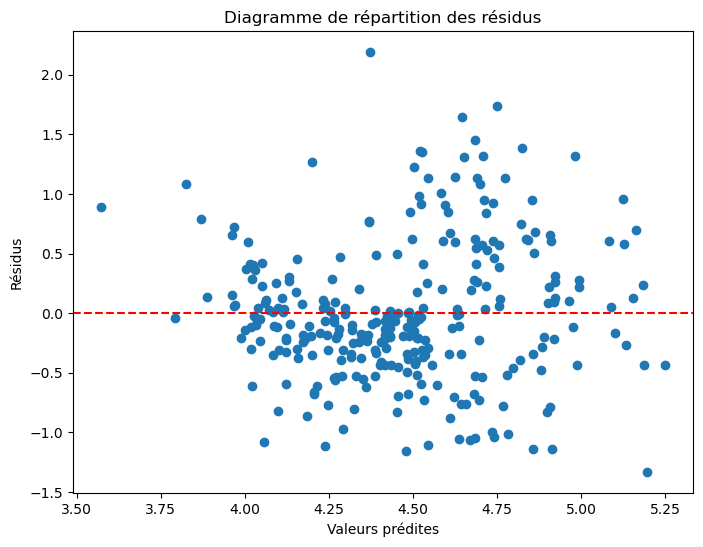

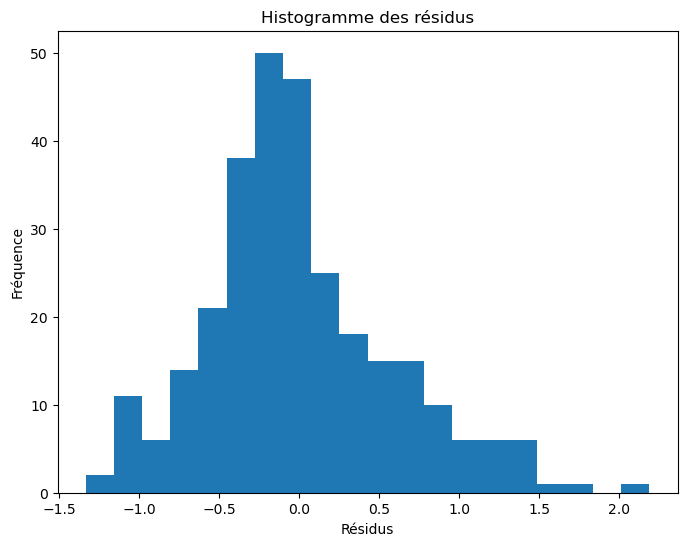

Scores de validation croisée : [0.23269456 0.23621595 0.28024507 0.30439551 0.19447695]
Score moyen de validation croisée : 0.24960560930798134
                            OLS Regression Results                            
Dep. Variable:             margin_low   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     203.6
Date:                Sat, 04 May 2024   Prob (F-statistic):           1.41e-76
Time:                        19:29:45   Log-Likelihood:                -997.81
No. Observations:                1170   AIC:                             2002.
Df Residuals:                    1167   BIC:                             2017.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025

In [15]:
# Pour imputer les données nous allons utiliser un algorithme, la régression linéaire multiple :
    # 1. Visualisation de corrélation assez élevée entre le champ cible margin_low et les champs margin_up (0.43), height_right (0.39) et height_left (0.30)
        # Voir matrice de corrélation dans la suite
        # Le fait qu'il y ait des corrélations indique qu'il existe une relation linéaire entre ces variables, ce qui rend cette méthode appropriée
    # 2. Cette méthode est un modèle simple à interpréter
    # 3. Permet d'observer un phénomène quantitatif et à l'expliquer par un certain nombres de variable quantitative - ce qui est notre cas
    
# Etapes de mise en place de la régression linéaire multiple 
    # 1. Sélectionner les données avec toutes les valeurs présentes pour les champs concernés, cible et explicative -  Ce seront les données d'entrainements du modèle
        # Sélection des données et suppression des valeurs NA, car on doit avoir seulement des valeurs assignées pour l'entrainement du modèle
train_data_reg_lin_mult = billets.dropna(subset=['is_genuine','margin_low', 'margin_up', 'height_right'])
        # Filtre pour garder seulement les variables explicatives 
X = train_data_reg_lin_mult[['is_genuine','margin_up', 'height_right']]
        # Filtre pour garder seulement la variable cible à prédire
y = train_data_reg_lin_mult['margin_low']

    # 2. Division des données en ensemble de données d'entrainement et de test - 80 % entrainement et 20 % test
        # Le random state est un nombre aléatoire qui répetera la même répartition si on relance le code, chaque nouveau code se composera d'une répartition différente et fixe - c'est comme un seed
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X['is_genuine'])

X_train_split = X_train_split[['margin_up', 'height_right']]
X_test_split = X_test_split[['margin_up', 'height_right']]


    # 3. Normalisation des données d'entrainements des variables explicatives (pas utile pour la variable cible) et utilisation de cette normalisation pour les données de test 
        # Permet d'avoir un traitement identique entre les données d'entrainement et de test, donnant un résultat plus cohérents et fiables
        # Initialisation et ajustement du scaler sur les données d'entraînement - Utilisation du standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)

        # Application de la même normalisation aux données de test
X_test_scaled = scaler.transform(X_test_split)

    # 4. Création et entrainement du modèle de régression linéaire multiple 
model = LinearRegression()
model.fit(X_train_scaled, y_train_split)


X_test_scaled

    
    # 5. Prédiction sur les données de test - Utile pour évaluer la qualité du modèle
        # Plusieurs méthodes à cotrôler :
            # a. Coefficient de détermination R2 - Possible avec Scikit learn - Mesure la proportion de variance de la variable cible qui est prédictible à partir des variables explicatives. Si proche de 1 alors bon ajustement du modèle aux données
            # b. Les résidus - Possible avec Scikit learn - Représente les écarts entre les valeurs réelles et les valeurs prédites - Possibilité d'examiner la distribution des résidus pour voir s'ils suivent une distribution normale et qu'ils sont homogènes
            # c. La validation croisée - Possible avec Scikit learn - Permet d'estimer les performances du modèle sur plusieurs split de données, donnant une valeur de performance robuste car obtenu sur un ensemble plus grand de données
            # e. Visualiser via stat model le détail des données concernant la qualité du modèle la significativité des variables dans le modèle (si elles sont utiles au modèle)
            # f. Visualiser la colinéarité via le VIF (Calcul du facteur d'inflation de la variance)
                # Permet de voir si des variables explicatives apportent la même information
        # Prédiction sur les données de test - Utile pour obtenir le R2 et les résidus        
y_pred = model.predict(X_test_scaled)

        # a. Calcul du coefficient de détermination (R²) - utilisation de la méthode r2_score
r2 = r2_score(y_test_split, y_pred)
print("Coefficient de détermination (R²) :", r2)

        # b. Analyse des résidus 
        # Calcul des résidus, avec les valeurs réelles de test - les valeurs prédites par le modèle
residuals = y_test_split - y_pred
        # Utilisation d'un diagramme de répartition des résidus pour visualiser les résidus
            # Il montre la répartition des résidus par rapport aux valeurs prédites
            # Objectif : Avoir une dispersion uniforme des résidus autour de zéro, ce qui indiquerait que les erreurs sont réparties de manière aléatoire et homogène
            # Interprétation : Si le nuage de points semble aléatoire et que les résidus sont distribués uniformément autour de la ligne zéro -> erreurs de prédiction sont bien réparties et que le modèle ne présente pas de biais systématique
                # 
diag_repart_residus_reg_lin_mult(residuals, y_pred)
        # Utilisation d'un histogramme 
            # Il montre la distribution des résidus
            # Objectif : Avoir une distribution quasiment normale, donc la majorité des résidus proches de 0 et donc un effet symétrique
            # Interprétation : Si l'histogramme est en forme de cloche centrée autour de zéro, cela indique que les résidus suivent approximativement une distribution normale. Si on a des asymétries ou valeurs aberrante, cela peut indiquer des problèmes de modèle
histo_repart_residus_reg_lin_mult(residuals)

        # c. Validation croisée
            # Choix de faire une validation croisée à 5 itérations différentes de split de données
            # Interprétation : La moyenne doit être proche de 1 pour dire que la performance du modèle est bonne SINON le modèle est nulle
cv_scores = cross_val_score(model, X_train_scaled, y_train_split, cv=5)
print("Scores de validation croisée :", cv_scores)
print("Score moyen de validation croisée :", np.mean(cv_scores))

        # e. Summary via stat models qui permet d'afficher un détail sur les informations du modèle, des variables, etc. 
            # Add constant for intercept
X_train_scaled = sm.add_constant(X_train_scaled)

            # Fit the model
model_stat_model = sm.OLS(y_train_split, X_train_scaled).fit()

            # Print the summary
print(model_stat_model.summary())

        # f. Test de VIF pour visualiser la colinéarité des variables explicatives - voir si des variables sont corrélées ensemble et donc apportent la même information, donc inutile
            # Entre 0 et 10, si supérieur à 10 colinéarité problématique
        
X_train = train_data_reg_lin_mult[['margin_up', 'height_right']]

# Add constant for intercept
X_train = sm.add_constant(X_train)

vif_data = X_train.drop(columns='const')
vif = pd.DataFrame()
vif["Variable"] = vif_data.columns
vif["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

print(vif)

# Conclusion global : 
    # 1er version, utilisation de 3 variables explicatives les plus corrélées à margin_low, avec données normalisées
        # Coefficient de détermination ~ 0.28 
        # Résidus correctes
        # Validation croisée ~ 0.26
        # Colinéarité énorme entre height right et height left - ~ 7000 - ils apportent la même information pas utile
    # 2 eme version, utilisation de 3 variables explicatives les plus corrélées à margin_low, avec données de bases
        # Tout pareil
    # 3 eme version, utilisation de 2 variabkes explicatives, suppression de height left, la moins corrélée de margin low, avec données normalisées
        # Coefficient de détermination ~ 0.26
        # Résidus correctes
        # Validation croisée ~ 0.25
        # Grosse colinéarité height right et margin up - ~ 199
    # 4 eme version, utilisation d'une variables explicatives, suppression de height right, on garde seulement margin up, la plus corrélée de margin low, avec données normalisées
        # Coefficient de détermination ~ 0.18 - perte d'information
        # Résidus mauvais
        # Validation croisée ~ 0.20
        # Plus de colinéarité car qu'une seule variable explicative
    # 5 eme et dernière version, utilisation de 2 variables explicatives, height right et margin up, avec données normalisées ET répartition égale de la classe "is_genuine" dans les données de test et d'entrainement - pour avoir la même part et pas plus de vrai que de faux dans les données entrainements ou inversement
        # Coefficient de détermination ~ 0.26
        # Résidus bon
        # Validation croisée ~ 0.25
        # Grosse colinéarité height right et margin up - ~ 199
        
    # Choix d'imputer les données avec cette modélisation qui n'est pas très bonne MAIS qui restera toujours meilleure qu'une imputation à la moyenne OU médiane
        # Ce choix s'est fait vu que c'était une imputation d'un petit pourcentage de données du jeu de données MAIS dans le cas d'une prédiction de données comme objectif principal, le modèle n'aurait pas été utilisé

#### Prédiction des valeurs ET imputation des données (quand le modèle est OK)

In [16]:
    # 6. Utilisez le modèle pour prédire les valeurs manquantes dans margin_low
missing_data = billets[billets['margin_low'].isnull()]
X_missing = missing_data[['margin_up', 'height_right']]
X_missing_scaled = scaler.transform(X_missing)

# Prédiction des valeurs avec le modèle entrainé et validé sur les données ou margin_low est NULL (les 37 valeurs manquantes)
predicted_values = model.predict(X_missing_scaled)

    # 7. Remplacez les valeurs manquantes dans margin_low par les valeurs prédites
billets.loc[billets['margin_low'].isnull(), 'margin_low'] = predicted_values

In [17]:
# Connaitre le nombre de valeurs null
print(billets.info())
# Connaitre le % de valeurs manquantes par colonne
print(billets.isna().mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
 7   id            1500 non-null   int64  
dtypes: bool(1), float64(6), int64(1)
memory usage: 83.6 KB
None
is_genuine      0.0
diagonal        0.0
height_left     0.0
height_right    0.0
margin_low      0.0
margin_up       0.0
length          0.0
id              0.0
dtype: float64


## Valeurs abberantes

In [18]:
# Visualisation des valeurs aberrantes (hors norme) pour chaque variable - utilisation de la méthode IQR

    # A. Variable "diagonal"
        # Appel de la fonction permettant d'exécuter la méthode IQR pour la variable souhaitée
methode_iqr_aberrante("diagonal")

    # B. Variable "height_left"
        # Appel de la fonction permettant d'exécuter la méthode IQR pour la variable souhaitée
methode_iqr_aberrante("height_left")

    # C. Variable "height_right"
        # Appel de la fonction permettant d'exécuter la méthode IQR pour la variable souhaitée
methode_iqr_aberrante("height_right")

    # D. Variable "margin_low"
        # Appel de la fonction permettant d'exécuter la méthode IQR pour la variable souhaitée
methode_iqr_aberrante("margin_low")

    # E. Variable "margin_up"
        # Appel de la fonction permettant d'exécuter la méthode IQR pour la variable souhaitée
methode_iqr_aberrante("margin_up")

    # F. Variable "length"
        # Appel de la fonction permettant d'exécuter la méthode IQR pour la variable souhaitée
methode_iqr_aberrante("length")

+--------+----------+
|   id   | diagonal |
+--------+----------+
| 1277.0 |  173.01  |
| 828.0  |  172.92  |
| 842.0  |  172.89  |
| 1022.0 |  172.89  |
| 1388.0 |  171.05  |
| 729.0  |  171.04  |
| 1142.0 |  171.04  |
+--------+----------+
+--------+-------------+
|   id   | height_left |
+--------+-------------+
| 1090.0 |   104.88    |
|  0.0   |   104.86    |
| 1150.0 |   104.86    |
| 1382.0 |   104.85    |
| 224.0  |    103.2    |
| 292.0  |   103.14    |
+--------+-------------+
+--------+--------------+
|   id   | height_right |
+--------+--------------+
|  0.0   |    104.95    |
| 1484.0 |    104.95    |
| 1199.0 |    104.87    |
| 1321.0 |    104.86    |
| 1331.0 |    104.83    |
| 761.0  |    103.04    |
|  77.0  |    103.03    |
| 176.0  |    102.97    |
| 193.0  |    102.95    |
| 522.0  |    102.91    |
| 251.0  |    102.82    |
+--------+--------------+
+--------+------------+
|   id   | margin_low |
+--------+------------+
| 1290.0 |    6.9     |
| 1124.0 |    6.7     

# 4. Analyses Descriptives / Univariées 

In [19]:
# Création d'un rapport tout fait via ydata profiling - Permet de faire une première analyse rapide

from ydata_profiling import ProfileReport

profile = ProfileReport(billets, title="Profiling Report")

profile.to_file("report.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
# Nombre de billets présents

print("Présence de ",billets.shape[0] ," billets")

# Nombre de variables présentes sur chaque billet (-1 pour supprimer la colonne des id)

print("Nombre de variables :", billets.shape[1]-1)

# Statistique descriptive de base des données pour tous les billets

billets.describe()

Présence de  1500  billets
Nombre de variables : 7


,diagonal,height_left,height_right,margin_low,margin_up,length,id
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,171.958440,104.029533,103.920307,4.483758,3.151473,112.67850,749.500000
std,0.305195,0.299462,0.325627,0.658090,0.231813,0.87273,433.157015
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000,0.000000
25%,171.750000,103.820000,103.710000,4.020000,2.990000,112.03000,374.750000
50%,171.960000,104.040000,103.920000,4.320000,3.140000,112.96000,749.500000
75%,172.170000,104.230000,104.150000,4.863849,3.310000,113.34000,1124.250000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000,1499.000000


In [21]:
# Statistique descriptive de base des données pour les billets comptabilisés comme vrai
billets[billets["is_genuine"] == True].describe()

,diagonal,height_left,height_right,margin_low,margin_up,length,id
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000
mean,171.987080,103.949130,103.80865,4.121513,3.05213,113.202430,499.500000
std,0.300441,0.300231,0.29157,0.320350,0.18634,0.359552,288.819436
min,171.040000,103.140000,102.82000,2.980000,2.27000,111.760000,0.000000
25%,171.790000,103.740000,103.61000,3.910000,2.93000,112.950000,249.750000
50%,171.990000,103.950000,103.81000,4.120000,3.05000,113.205000,499.500000
75%,172.200000,104.140000,104.00000,4.350000,3.18000,113.460000,749.250000
max,172.920000,104.860000,104.95000,5.040000,3.74000,114.440000,999.000000


In [22]:
# Statistique descriptive de base des données pour les billets comptabilisés comme faux
billets[billets["is_genuine"] == False].describe()

,diagonal,height_left,height_right,margin_low,margin_up,length,id
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,171.901160,104.190340,104.143620,5.208248,3.350160,111.630640,1249.500000
std,0.306861,0.223758,0.270878,0.553736,0.180498,0.615543,144.481833
min,171.040000,103.510000,103.430000,3.820000,2.920000,109.490000,1000.000000
25%,171.690000,104.040000,103.950000,4.820000,3.220000,111.200000,1124.750000
50%,171.910000,104.180000,104.160000,5.180000,3.350000,111.630000,1249.500000
75%,172.092500,104.332500,104.320000,5.590000,3.472500,112.030000,1374.250000
max,173.010000,104.880000,104.950000,6.900000,3.910000,113.850000,1499.000000


## Analyses univariées

### Répartition des billets vrai ou faux

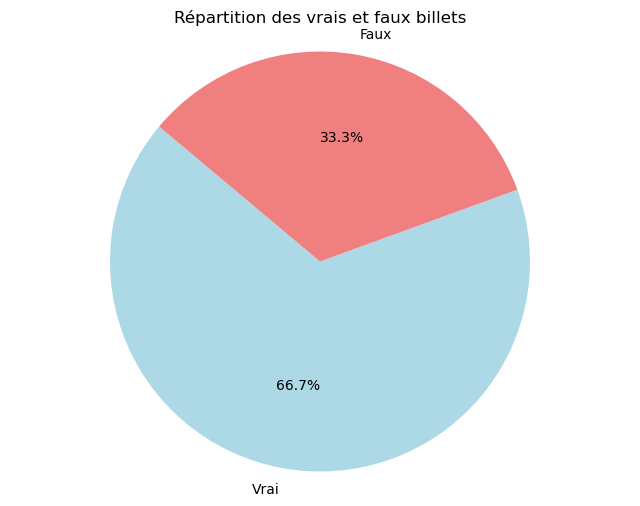

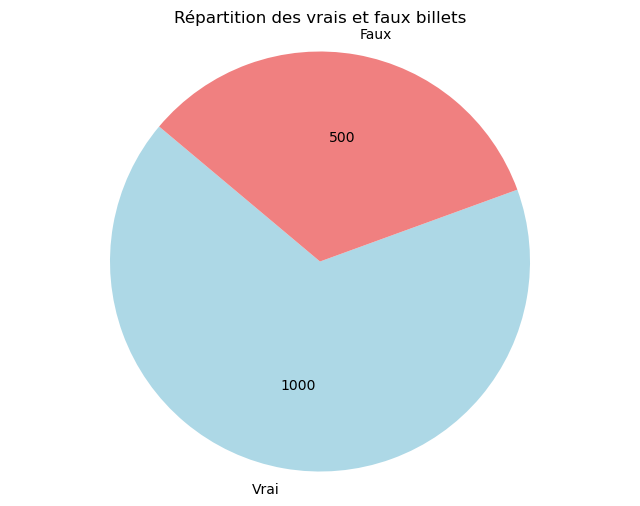

In [23]:
# A. Compter le nombre de valeurs "true" et "false" - En pourcentage
true_count = len(billets[billets['is_genuine'] == True])
false_count = len(billets[billets['is_genuine'] == False])

# Créer une liste contenant les nombres de chaque catégorie
sizes = [true_count, false_count]

# Étiquettes pour les secteurs
labels = ['Vrai', 'Faux']

# Couleurs pour chaque secteur
colors = ['lightblue', 'lightcoral']

# Créer le diagramme en secteurs
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)

# Titre du diagramme
plt.title('Répartition des vrais et faux billets')

# Afficher le diagramme
plt.axis('equal')  # Assure que le diagramme est un cercle
plt.show()


# B. Compter le nombre de valeurs "true" et "false" - En donnéees réelles
true_count = len(billets[billets['is_genuine'] == True])
false_count = len(billets[billets['is_genuine'] == False])

# Créer une liste contenant les nombres de chaque catégorie
sizes = [true_count, false_count]

# Étiquettes pour les secteurs
labels = ['Vrai', 'Faux']

# Couleurs pour chaque secteur
colors = ['lightblue', 'lightcoral']

# Fonction pour afficher le nombre réel au lieu du pourcentage
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_format

# Créer le diagramme en secteurs avec le nombre réel
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct=autopct_format(sizes), startangle=140)

# Titre du diagramme
plt.title('Répartition des vrais et faux billets')

# Afficher le diagramme
plt.axis('equal')  # Assure que le diagramme est un cercle
plt.show()

### Distribution des variables - vrai - faux billets

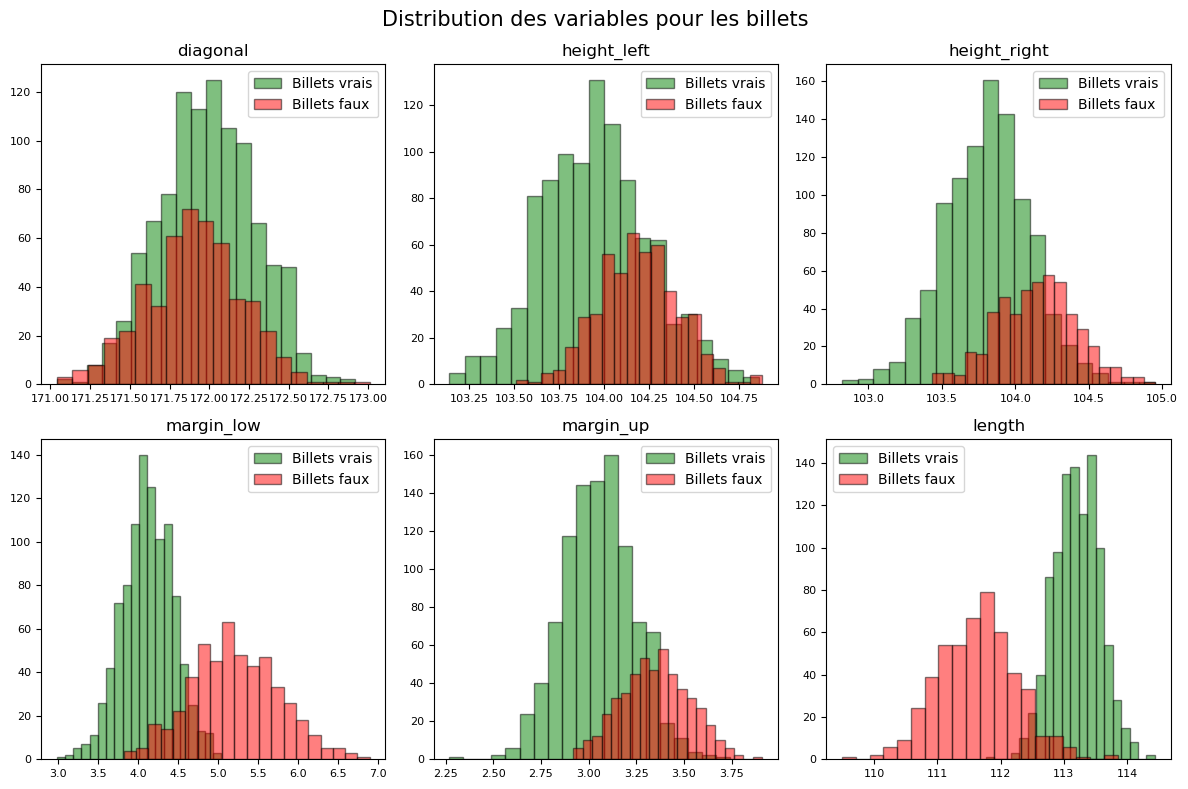

In [24]:
# A. Visualisation de la distribution, pour apercevoir la forme globale des données, voir des tendances, etc.

# Configuration de la forme du graphique
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# Liste des colonnes à traiter et afficher
columns = billets[["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]]

# Boucle pour effectuer l'affichage de toutes les variables
for i, colonne in enumerate(columns):
    # Calcul des indices de la sous-figure
    row_index = i // 3
    col_index = i % 3


    # Distribution sur les billets vrais
    axs[row_index, col_index].hist(billets[billets['is_genuine'] == True][colonne], edgecolor='k', bins=20, color='green', alpha=0.5, label='Billets vrais')
    
    # Distribution sur les billets faux
    axs[row_index, col_index].hist(billets[billets['is_genuine'] == False][colonne], edgecolor='k', bins=20, color='red', alpha=0.5, label='Billets faux')
    
    # Ajouter un titre à chaque sous-figure
    axs[row_index, col_index].set_title(colonne, size=12)
    axs[row_index, col_index].tick_params(axis='both', which='both', labelsize=8)
    axs[row_index, col_index].legend()

# Titre global du graphique
fig.suptitle('Distribution des variables pour les billets', size=15)

# Ajustement de l'espacement entre les sous-graphiques
plt.tight_layout()

# Affichage du graphique
plt.show()

### Dispersion des variables - all - vrai - faux billets

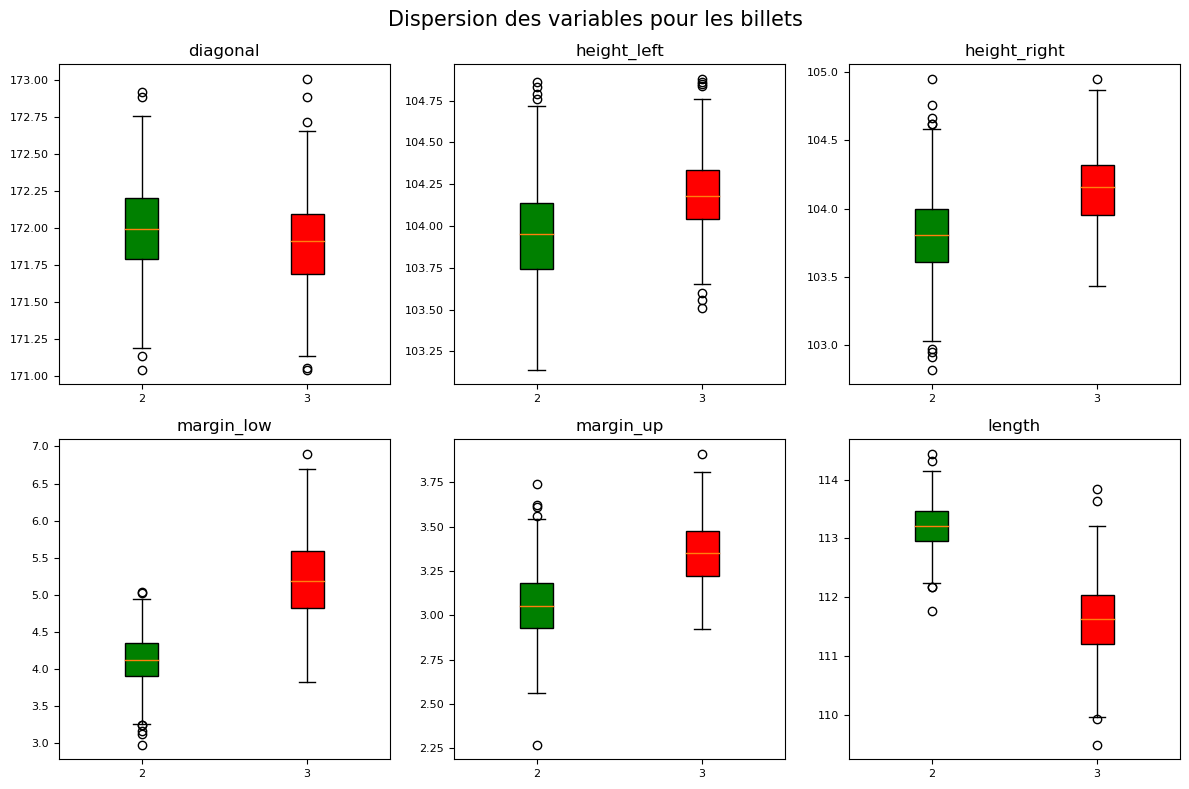

In [25]:
# B. Visualisation de la dispersion des données, pour voir les valeurs aberrantes, etc.

# Configuration de la forme du graphique
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

# Liste des colonnes à traiter et afficher
columns = billets[["diagonal", "height_left", "height_right", "margin_low", "margin_up", "length"]]

# Couleur à utiliser pour tous les boxplots
#boxplot_color = "red"

# Boucle pour effectuer l'affichage de toutes les variables
for i, colonne in enumerate(columns):
    # Calcul des indices de la sous-figure
    row_index = i // 3
    col_index = i % 3

    # Boxplot sur les billets vrais
    axs[row_index, col_index].boxplot(billets[billets['is_genuine'] == True][colonne], positions=[2], widths=0.2, patch_artist=True, boxprops=dict(facecolor='green'))
    
    # Boxplot sur les billets faux
    axs[row_index, col_index].boxplot(billets[billets['is_genuine'] == False][colonne], positions=[3], widths=0.2, patch_artist=True, boxprops=dict(facecolor='red'))
    
    # Ajouter un titre à chaque sous-figure
    axs[row_index, col_index].set_title(colonne, size=12)
    axs[row_index, col_index].tick_params(axis='both', which='both', labelsize=8)

# Titre global du graphique
fig.suptitle('Dispersion des variables pour les billets', size=15)

# Ajustement de l'espacement entre les sous-graphiques
plt.tight_layout()

# Affichage du graphique
plt.show()

## Analyses bivariées

### Matrice de corrélation entre les variables - all - vrai - faux billets

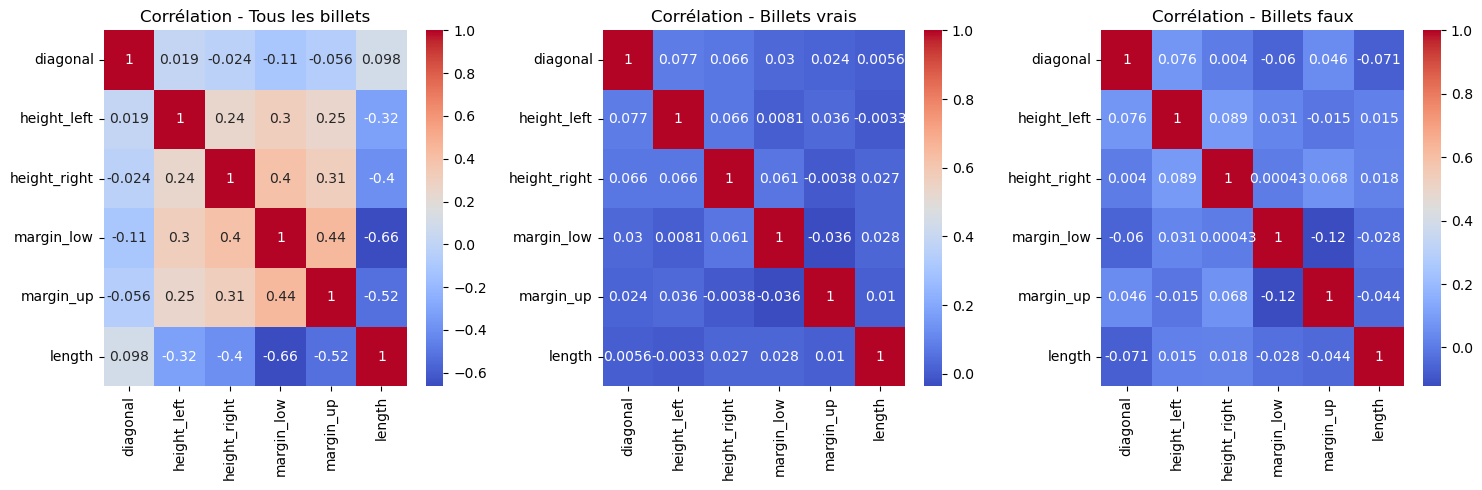

In [26]:
# Mise en place d'une Heatmap pour visualiser les corrélations entre les variables pour les différents groupes de données (all billets, vrais et faux)
    # Je pense que c'est seulement interressant sur tous les billets, pas interressant en prenant soit seulement les billets vrai ou faux

# Séparation des données en trois groupes : tous les billets, les vrais billets et les faux billets
all_billets = billets[['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
true_billets = billets[billets['is_genuine'] == True][['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]
false_billets = billets[billets['is_genuine'] == False][['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']]

# Calcul des corrélations pour chaque groupe
corr_all_billets = all_billets.corr(method='pearson')
corr_true_billets = true_billets.corr(method='pearson')
corr_false_billets = false_billets.corr(method='pearson')

# Création des trois sous-plots pour afficher les matrices de corrélation
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Heatmap pour tous les billets
sns.heatmap(corr_all_billets, annot=True, cmap='coolwarm', ax=axs[0])
axs[0].set_title('Corrélation - Tous les billets')

# Heatmap pour les billets vrais
sns.heatmap(corr_true_billets, annot=True, cmap='coolwarm', ax=axs[1])
axs[1].set_title('Corrélation - Billets vrais')

# Heatmap pour les billets faux
sns.heatmap(corr_false_billets, annot=True, cmap='coolwarm', ax=axs[2])
axs[2].set_title('Corrélation - Billets faux')

# Ajustement de l'espacement entre les sous-graphiques
plt.tight_layout()

# Affichage du graphique
plt.show()

### Pair plot - vrai - faux billets

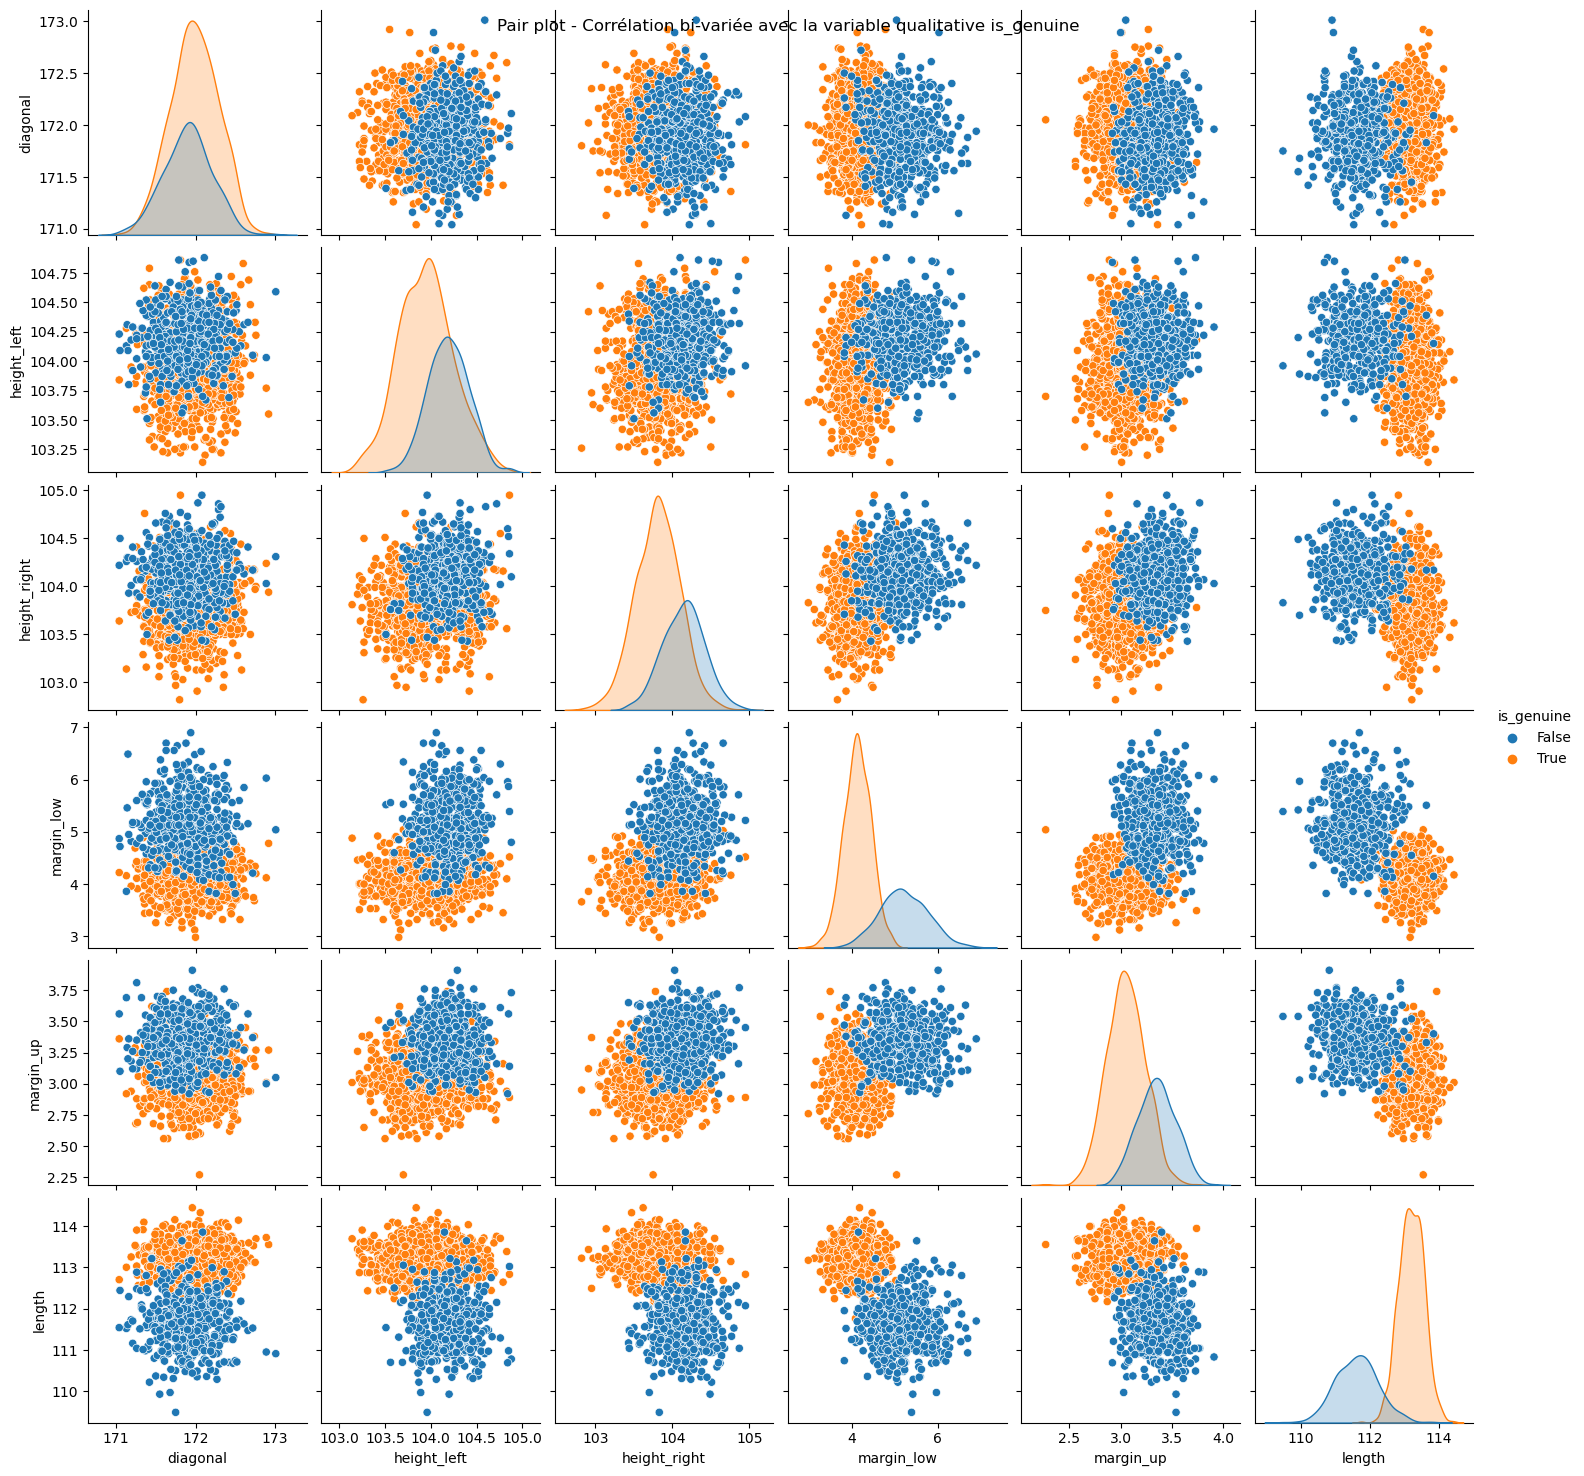

Corrélations point-biserial avec la variable qualitative is_genuine :
              Point-biserial correlation
diagonal                        0.132756
height_left                    -0.379833
height_right                   -0.485092
margin_low                     -0.778712
margin_up                      -0.606262
length                          0.849285


In [27]:
# Utilisation d'un pair plot pour calculer le coefficient de corrélation de point biserial, qui est une mesure de la corrélation entre une variable continue et une variable binaire.

# Sélection des variables continues et de la variable qualitative
continuous_vars = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
qualitative_var = 'is_genuine'

# Calcul des corrélations point-biserial
correlations = {}
for var in continuous_vars:
    # Calcul de la corrélation point-biserial
    corr, _ = pointbiserialr(billets[var], billets[qualitative_var])
    correlations[var] = corr

# Création du DataFrame contenant les corrélations
correlations_df = pd.DataFrame(correlations.values(), index=correlations.keys(), columns=['Point-biserial correlation'])

# Affichage du pair plot
sns.pairplot(data=billets, vars=continuous_vars, hue=qualitative_var)
plt.suptitle('Pair plot - Corrélation bi-variée avec la variable qualitative is_genuine')
plt.show()

# Affichage des corrélations point-biserial
print("Corrélations point-biserial avec la variable qualitative is_genuine :")
print(correlations_df)

In [28]:
# Export du dataframe "all_dataframe" à utiliser pour la suite
billets.to_csv("billet_prep_donnees.csv", index=False)